In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv("Expanded_data_with_more_features.csv")
print(df.head())

   Unnamed: 0  Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0           0  female         NaN   bachelor's degree      standard     none   
1           1  female     group C        some college      standard      NaN   
2           2  female     group B     master's degree      standard     none   
3           3    male     group A  associate's degree  free/reduced     none   
4           4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  W

In [79]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  str    
 2   EthnicGroup          28801 non-null  str    
 3   ParentEduc           28796 non-null  str    
 4   LunchType            30641 non-null  str    
 5   TestPrep             28811 non-null  str    
 6   ParentMaritalStatus  29451 non-null  str    
 7   PracticeSport        30010 non-null  str    
 8   IsFirstChild         29737 non-null  str    
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  str    
 11  WklyStudyHours       29686 non-null  str    
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), str(10)
memory usage: 

In [81]:
df.isnull().sum()

Unnamed: 0                0
Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

In [82]:
df = df.drop("Unnamed: 0", axis=1)
print(df.head())

   Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0  female         NaN   bachelor's degree      standard     none   
1  female     group C        some college      standard      NaN   
2  female     group B     master's degree      standard     none   
3    male     group A  associate's degree  free/reduced     none   
4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  WritingScore  
0            < 5         71            71            74  


In [83]:
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


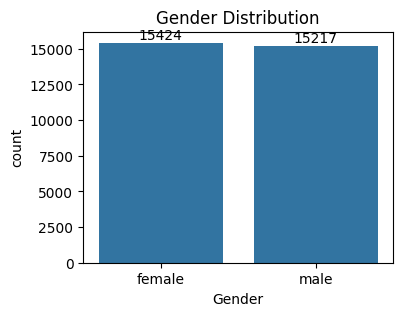

In [84]:
plt.figure(figsize=(4, 3))
ax = sns.countplot(data=df, x="Gender")
ax.bar_label(ax.containers[0])
plt.title("Gender Distribution")
plt.show()

In [85]:
gb = df.groupby("ParentEduc", as_index=False)[["MathScore", "ReadingScore", "WritingScore"]].mean()
print(gb)

           ParentEduc  MathScore  ReadingScore  WritingScore
0  associate's degree  68.365586     71.124324     70.299099
1   bachelor's degree  70.466627     73.062020     73.331069
2         high school  64.435731     67.213997     65.421136
3     master's degree  72.336134     75.832921     76.356896
4        some college  66.390472     69.179708     68.501432
5    some high school  62.584013     65.510785     63.632409


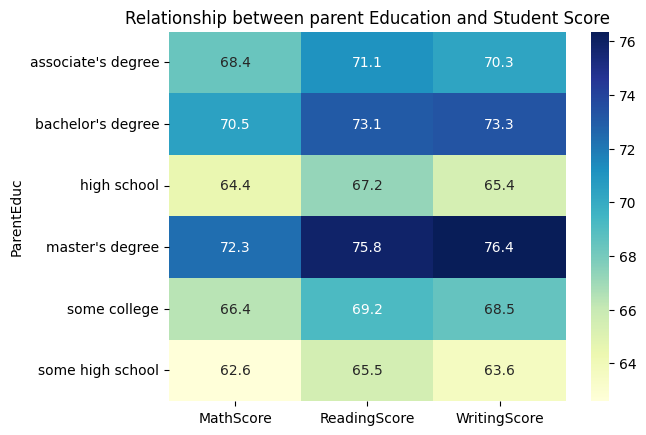

In [86]:
sns.heatmap(gb.set_index("ParentEduc"), annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Relationship between parent Education and Student Score")
plt.show()

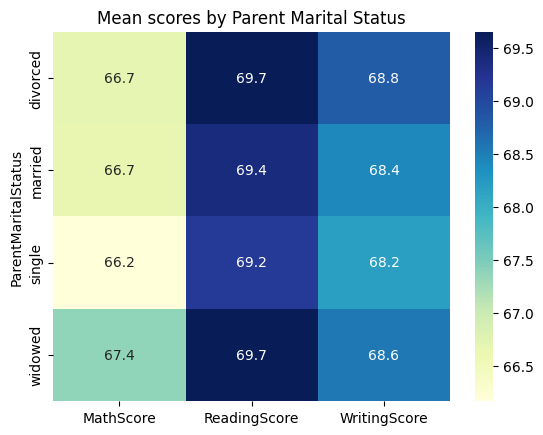

  ParentMaritalStatus  MathScore  ReadingScore  WritingScore
0            divorced  66.691197     69.655011     68.799146
1             married  66.657326     69.389575     68.420981
2              single  66.165704     69.157250     68.174440
3             widowed  67.368866     69.651438     68.563452


In [87]:
gb1 = df.groupby("ParentMaritalStatus", as_index=False)[["MathScore", "ReadingScore", "WritingScore"]].mean()
sns.heatmap(gb1.set_index("ParentMaritalStatus"), annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Mean scores by Parent Marital Status")
plt.show()
print(gb1)

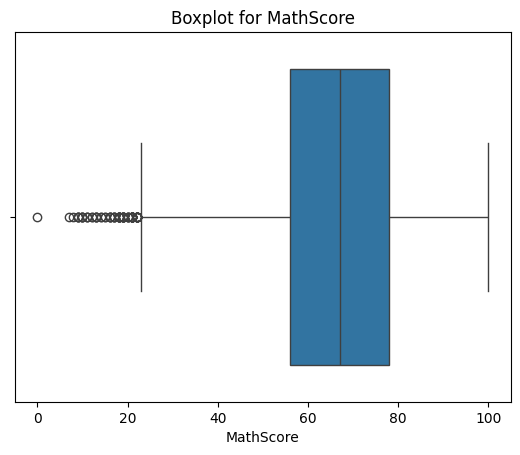

In [88]:
sns.boxplot(data = df, x = "MathScore")
plt.title("Boxplot for MathScore")
plt.show()

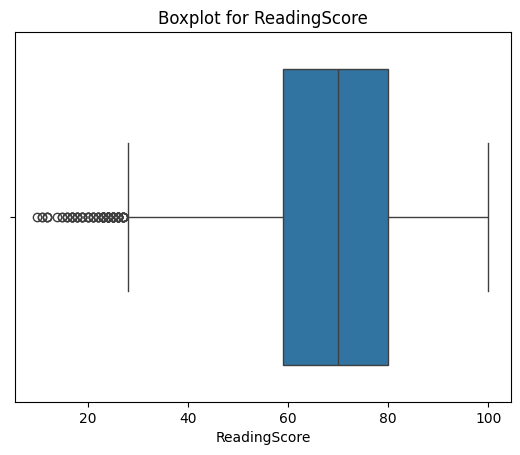

In [89]:
sns.boxplot(data = df, x = "ReadingScore")
plt.title("Boxplot for ReadingScore")
plt.show()

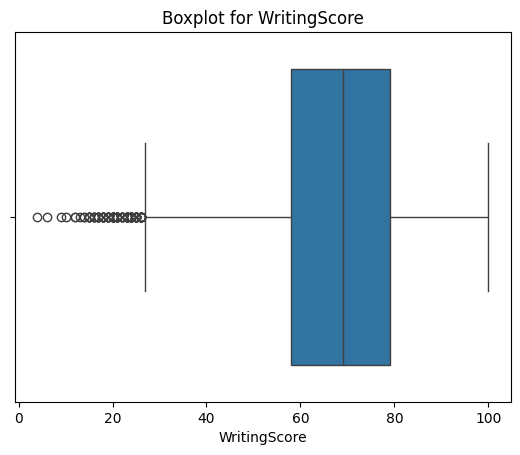

In [90]:
sns.boxplot(data = df, x = "WritingScore")
plt.title("Boxplot for WritingScore")
plt.show()

In [91]:
print(df["EthnicGroup"].unique())

<StringArray>
[nan, 'group C', 'group B', 'group A', 'group D', 'group E']
Length: 6, dtype: str


Distribution of Ethnic Groups

In [ ]:
groupA = df.loc[df["EthnicGroup"] == "GroupA"]
print(groupA)
